# Кластеризация

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm import tqdm
import os
import sys

sys.path.append('..')
from utils import dunn_index, compute_gap_statistic, get_cluster_report, get_centroid_examples

RANDOM_STATE = 42

Загрузка данных

In [2]:
df = pd.read_csv(
    "../data/split/02_text_for_vectorization.csv"
)

X_sbert = np.load(
    "../data/embeddings/sbert.npy"
)

# SBERT (all-MiniLM-L6-v2)

Нормализация

In [3]:
X_sbert_norm = normalize(X_sbert)

Подбор PCA

In [17]:
pca_dims = [50, 100, 200, None] 
k_range = range(5, 21)

results_sbert = []

for n_comp in pca_dims:
    print("=" * 80)
    print(f"PCA = {n_comp}")
    print("=" * 80)
    
    if n_comp != None:
        pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        X_current = pca.fit_transform(X_sbert_norm)
        print(f"После PCA: {X_current.shape}")
    else:
        X_current = X_sbert_norm
        print("Без PCA, используем исходные эмбеддинги")
    
    for k in tqdm(k_range, desc=f"KMeans with PCA={n_comp}"):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
        labels = km.fit_predict(X_current)
        
        sil = silhouette_score(X_current, labels)
        ch = calinski_harabasz_score(X_current, labels)
        db = davies_bouldin_score(X_current, labels)
        dunn = dunn_index(X_current, labels)
        gap = compute_gap_statistic(X_current, k)
        
        results_sbert.append({
            'pca_dim': n_comp,
            'k': k,
            'silhouette': sil,
            'calinski_harabasz': ch,
            'davies_bouldin': db,
            'dunn': dunn,
            'gap': gap,
            'wss': km.inertia_
        })

df_sbert_metrics = pd.DataFrame(results_sbert)

PCA = 50
После PCA: (10467, 50)


KMeans with PCA=50: 100%|██████████| 16/16 [01:03<00:00,  3.94s/it]


PCA = 100
После PCA: (10467, 100)


KMeans with PCA=100: 100%|██████████| 16/16 [01:34<00:00,  5.90s/it]


PCA = 200
После PCA: (10467, 200)


KMeans with PCA=200: 100%|██████████| 16/16 [02:26<00:00,  9.14s/it]


PCA = None
Без PCA, используем исходные эмбеддинги


KMeans with PCA=None: 100%|██████████| 16/16 [04:00<00:00, 15.02s/it]


In [18]:
df_sbert_metrics.to_csv("../data/results/metrics/sbert/sbert_kmeans_metrics.csv", index=False)

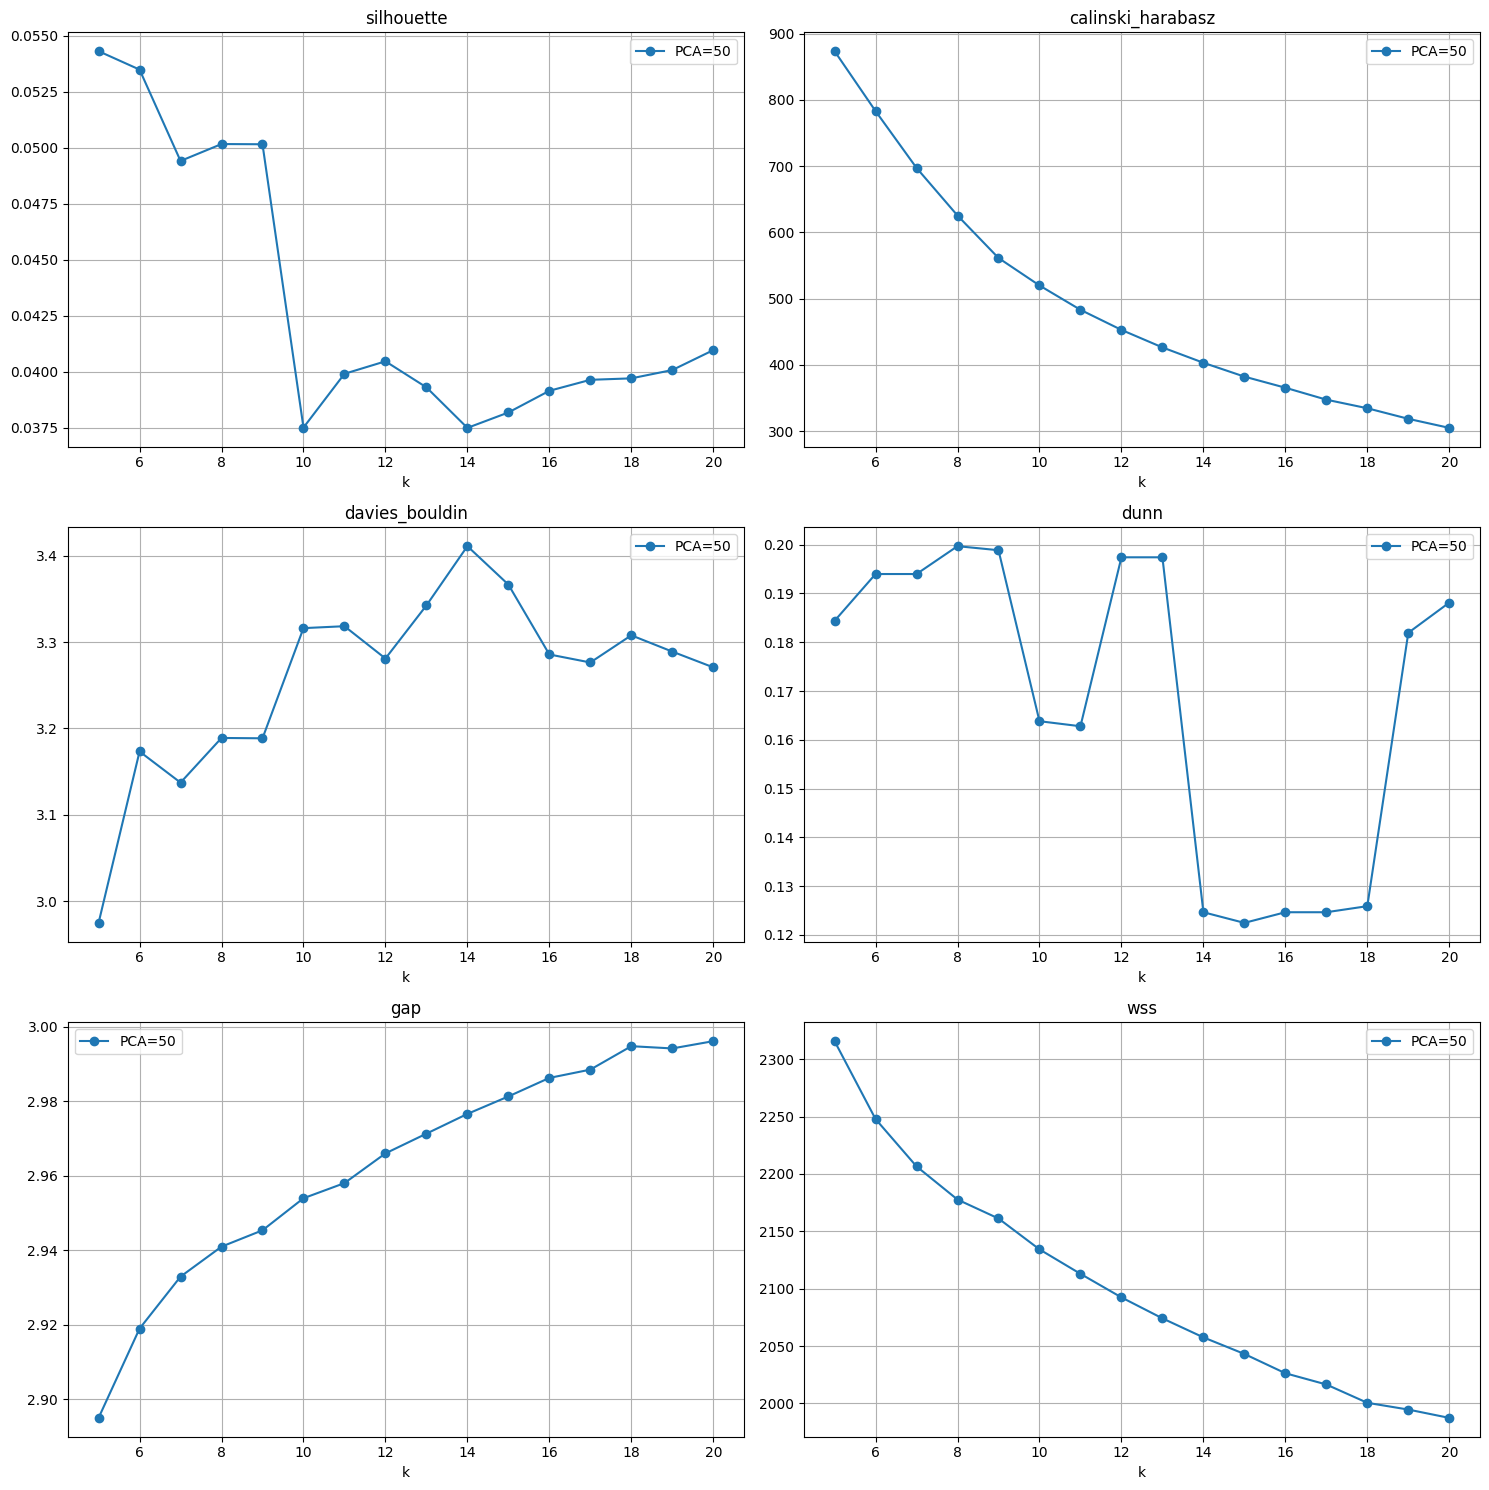

In [19]:
metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "dunn",
    "gap",
    "wss"
]

pca_candidates = [50]

n_cols = 2
n_rows = 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(15, 5 * n_rows)
)
axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    
    for pca_dim in pca_candidates:
        # Для None / NaN
        if pd.isna(pca_dim):
            subset = df_sbert_metrics[
                df_sbert_metrics["pca_dim"].isna()
            ]
            label = "PCA=None"
        else:
            subset = df_sbert_metrics[
                df_sbert_metrics["pca_dim"] == pca_dim
            ]
            label = f"PCA={pca_dim}"
        
        ax.plot(
            subset["k"],
            subset[metric],
            marker="o",
            label=label
        )
    
    ax.set_title(metric)
    ax.set_xlabel("k")
    ax.grid(True)
    ax.legend()

plt.tight_layout()

os.makedirs(
    "../data/plots/sbert/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/sbert/kmeans/sbert_kmeans.png",
    dpi=200,
    bbox_inches='tight'
)
plt.show()

В качестве размерности выбираем 50 компонент PCA: при ней лучшие silhouette, Calinski-Harabasz и Davies-Bouldin, а увеличение размерности только ухудшает метрики из-за шума.

Для дальнейшего анализа возьмем k: 8, 9, 10, 12, 13, 14, 15, 16, 18

In [4]:
FINAL_PCA_SBERT = 50

pca_final = PCA(
    n_components=FINAL_PCA_SBERT,
    random_state=RANDOM_STATE
)

X_sbert_final = pca_final.fit_transform(
    X_sbert_norm
)

In [137]:
k_candidates = [8, 9, 10, 12, 13, 14, 15, 16, 18]

In [ ]:
cluster_sizes_report = {}

for k in k_candidates:

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(
        X_sbert_final
    )

    df_temp = df.copy()

    df_temp['cluster'] = labels

    report = get_cluster_report(
        df_temp,
        'cluster'
    )

    cluster_sizes_report[k] = report

summary_data = []

for k in k_candidates:

    report = cluster_sizes_report[k]

    summary_data.append({
        'k': k,
        'min_cluster': report['min_size'],
        'max_cluster': report['max_size'],
        'max_cluster_pct':
            f"{report['max_size_pct']:.1%}"
    })

df_summary_sbert = pd.DataFrame(summary_data)

df_summary_sbert

,k,min_cluster,max_cluster,max_cluster_pct
0,8,409,2782,26.6%
1,9,374,2768,26.4%
2,10,375,2207,21.1%
3,12,315,2065,19.7%
4,13,312,2016,19.3%
5,14,303,1495,14.3%
6,15,296,1578,15.1%
7,16,145,1507,14.4%
8,18,143,1378,13.2%


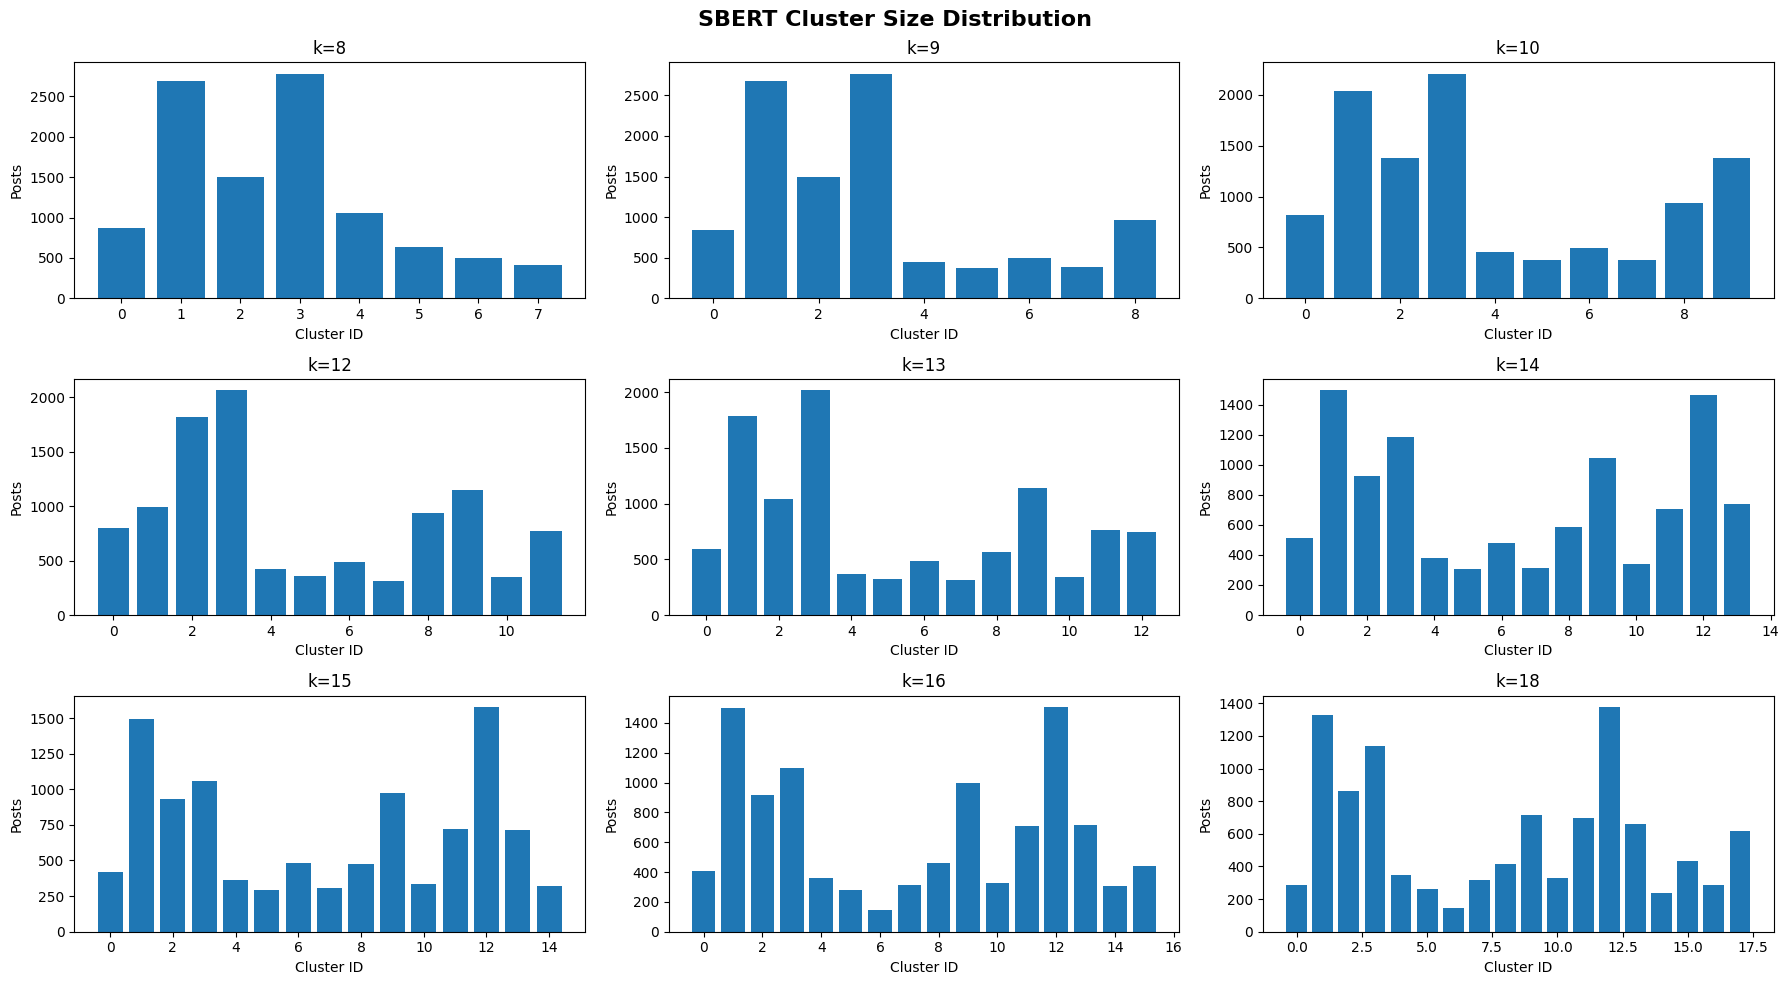

In [ ]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for idx, k in enumerate(k_candidates):

    sizes = cluster_sizes_report[k]['sizes']

    axes[idx].bar(
        range(len(sizes)),
        list(sizes.values())
    )

    axes[idx].set_title(f'k={k}')
    axes[idx].set_xlabel('Cluster ID')
    axes[idx].set_ylabel('Posts')

plt.suptitle(
    'SBERT Cluster Size Distribution',
    fontsize=16,
    fontweight='bold'
)

# axes[-1].axis('off')

plt.tight_layout()

os.makedirs(
    "../data/plots/sbert/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/sbert/kmeans/"
    "sbert_cluster_sizes.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Рассмотрим несколько кадидатов

In [133]:
final_candidates_sbert = [12, 13, 14, 15, 16]

Создание кластеров для каждого k

In [ ]:
base_examples_path = (
    "../data/results/candidate_examples/sbert"
)

base_clusters_path = (
    "../data/results/final_clusters/sbert"
)

os.makedirs(
    base_examples_path,
    exist_ok=True
)

os.makedirs(
    base_clusters_path,
    exist_ok=True
)

for k in final_candidates_sbert:

    print("\n" + "=" * 80)
    print(f"k = {k}")
    print("=" * 80)

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(
        X_sbert_final
    )

    df_cluster = df.copy()

    df_cluster['cluster'] = labels

    cluster_sizes = (
        df_cluster['cluster']
        .value_counts()
        .sort_index()
    )

    df_cluster['cluster_size'] = (
        df_cluster['cluster']
        .map(cluster_sizes)
    )

    centroid_examples = get_centroid_examples(
        X_sbert_final,
        labels,
        df,
        n_examples=50
    )

    # TXT
    output_txt = (
        f"{base_examples_path}/"
        f"sbert_k{k}_candidate_examples.txt"
    )

    with open(output_txt, "w", encoding="utf-8") as f:

        f.write("=" * 80 + "\n")
        f.write("SBERT + KMeans\n")
        f.write(f"k = {k}\n")
        f.write(
            "TOP-50 nearest centroid examples\n"
        )
        f.write("=" * 80 + "\n\n")

        f.write("CLUSTER SIZES:\n\n")

        for cluster_id, size in cluster_sizes.items():

            f.write(
                f"Cluster {cluster_id}: "
                f"{size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        for cluster_id in sorted(cluster_sizes.index):

            f.write(f"\n{'=' * 80}\n")

            f.write(
                f"CLUSTER {cluster_id} "
                f"({cluster_sizes[cluster_id]} posts)\n"
            )

            f.write(f"{'=' * 80}\n\n")

            examples = centroid_examples.get(
                cluster_id,
                {}
            )

            texts = examples.get('texts', [])

            distances = examples.get(
                'distances',
                []
            )

            for idx, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(
                    str(text)
                    .replace('\n', ' ')
                    .split()
                )

                f.write(
                    f"[{idx+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(f"{clean_text}\n\n")

    print(f"Сохранен TXT: {output_txt}")

   
    output_csv = (
        f"{base_clusters_path}/"
        f"sbert_k{k}_clusters.csv"
    )

    df_cluster[
        [
            'post_id',
            'channel_username',
            'text',
            'cluster',
            'cluster_size'
        ]
    ].to_csv(
        output_csv,
        index=False
    )

    print(f"Сохранен CSV: {output_csv}")



k = 12
Сохранен TXT: ../data/results/candidate_examples/sbert/sbert_k12_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/sbert/sbert_k12_clusters.csv

k = 13
Сохранен TXT: ../data/results/candidate_examples/sbert/sbert_k13_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/sbert/sbert_k13_clusters.csv

k = 14
Сохранен TXT: ../data/results/candidate_examples/sbert/sbert_k14_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/sbert/sbert_k14_clusters.csv

k = 15
Сохранен TXT: ../data/results/candidate_examples/sbert/sbert_k15_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/sbert/sbert_k15_clusters.csv

k = 16
Сохранен TXT: ../data/results/candidate_examples/sbert/sbert_k16_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/sbert/sbert_k16_clusters.csv


При k = 12 кластеры в целом выделяются, но остается слишком широкий и неоднородный кластер новостей ИИ и образования (1784 поста), а также заметно искусственное дробление тем СПбГУ и Сколтеха. Пересечения между кластерами пока высокие.

При k = 13 появляются четкие тематические кластеры, исчезают "мусорные" объединения, а искусственное дробление отсутствует. Однако опросы остаются внутри развлекательного кластера, что не позволяет анализировать их отдельно. 

k = 14 дает оптимальный баланс. Опросы и викторины выделяются в самостоятельный кластер. Исчезают слишком большие кластеры, тема инструментов и вайб-кодинга выделяется в отдельный кластер, а Telegram, Apple и игровая индустрия разделяются чисто. Пересечения минимальны, а фрагментация остается низкой.

При k = 15 начинается искусственное дробление: короткие дайджесты новостей в уникальном формате разрываются на два почти одинаковых кластера. Интерпретируемость падает.

k = 16 ведет к переобучению: Telegram разбивается на 3–4 слабо связанных кластера, появляются дублирующиеся темы.

### Итоговый выбор
**k = 14**. Кластеры семантически связны, хорошо интерпретируются, не перегружены шумом и не излишне дробят смыслы.

In [5]:
FINAL_K_SBERT = 14

Фиксируем финальную версию

In [6]:
pca_final = PCA(
    n_components=FINAL_PCA_SBERT,
    random_state=RANDOM_STATE
)

X_sbert_final = pca_final.fit_transform(
    X_sbert_norm
)


km_final = KMeans(
    n_clusters=FINAL_K_SBERT,
    random_state=RANDOM_STATE,
    n_init='auto'
)

labels_final = km_final.fit_predict(
    X_sbert_final
)


df_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_cluster_final['cluster_sbert'] = labels_final

cluster_sizes = (
    df_cluster_final['cluster_sbert']
    .value_counts()
    .sort_index()
)

df_cluster_final['cluster_sbert_size'] = (
    df_cluster_final['cluster_sbert']
    .map(cluster_sizes)
)

Добавим названия кластеров

In [23]:
cluster_names_sbert = {
    0: "Регулирование: финтех и цифровой рубль",
    1: "Наука и ИИ: Сколтех, Сбер, ВШЭ",
    2: "Университет: конференции и студенческие проекты",
    3: "IT-образование: олимпиады, стажировки, карьера",
    4: "Игры: Nintendo, Steam, Rockstar",
    5: "Новости: короткие дайджесты IT и крипты",
    6: "Telegram: новости, TON, Павел Дуров",
    7: "Apple: слухи, дизайн, iPhone",
    8: "Юмор: мемы и развлекательные посты",
    9: "Тренды ИИ: AGI, роботы, OpenAI, дата-центры",
    10: "Apple: официальные анонсы, iOS, презентации",
    11: "Наука и ИИ: интервью с учёными",
    12: "ИИ-инструменты: вайб-кодинг, генерация контента",
    13: "Интерактив: опросы, викторины",
}

In [24]:
df_cluster_final['cluster_sbert_name'] = (
    df_cluster_final['cluster_sbert']
    .map(cluster_names_sbert)
)

Посмотрим на распределение кластеров

In [25]:
distribution = (
    df_cluster_final[
        [
            'cluster_sbert',
            'cluster_sbert_name',
            'cluster_sbert_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_sbert')
)

distribution

,cluster_sbert,cluster_sbert_name,cluster_sbert_size
33,0,Регулирование: финтех и цифровой рубль,511
0,1,"Наука и ИИ: Сколтех, Сбер, ВШЭ",1495
19,2,Университет: конференции и студенческие проекты,924
18,3,"IT-образование: олимпиады, стажировки, карьера",1181
122,4,"Игры: Nintendo, Steam, Rockstar",382
763,5,Новости: короткие дайджесты IT и крипты,303
125,6,"Telegram: новости, TON, Павел Дуров",482
840,7,"Apple: слухи, дизайн, iPhone",312
121,8,Юмор: мемы и развлекательные посты,586
1,9,"Тренды ИИ: AGI, роботы, OpenAI, дата-центры",1046


Сохраняем

In [26]:
os.makedirs(
    "../data/results/final_examples/sbert",
    exist_ok=True
)

centroid_examples = get_centroid_examples(
    X_sbert_final,
    labels_final,
    df,
    n_examples=50
)

output_path = (
    "../data/results/final_examples/"
    "sbert/sbert_final_examples.txt"
)

with open(output_path, "w", encoding="utf-8") as f:

    f.write("=" * 80 + "\n")
    f.write("SBERT + KMeans FINAL CLUSTERIZATION\n")
    f.write(f"PCA = {FINAL_PCA_SBERT}\n")
    f.write(f"k = {FINAL_K_SBERT}\n")
    f.write("=" * 80 + "\n\n")

    f.write("CLUSTER SIZES:\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        size = cluster_sizes[cluster_id]

        name = cluster_names_sbert.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(
            f"Cluster {cluster_id} "
            f"({name}): {size} posts\n"
        )

    f.write("\n" + "=" * 80 + "\n\n")


    for cluster_id in sorted(cluster_sizes.index):

        name = cluster_names_sbert.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(f"\n{'=' * 80}\n")

        f.write(
            f"CLUSTER {cluster_id}: "
            f"{name}\n"
        )

        f.write(
            f"Posts: {cluster_sizes[cluster_id]}\n"
        )

        f.write(f"{'=' * 80}\n\n")

        texts = centroid_examples[
            cluster_id
        ]['texts']

        distances = centroid_examples[
            cluster_id
        ]['distances']

        for idx, (text, dist) in enumerate(
            zip(texts, distances)
        ):

            clean_text = ' '.join(
                str(text)
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[{idx+1}] "
                f"(distance: {dist:.4f})\n"
            )

            f.write(f"{clean_text}\n\n")


    f.write("\n" + "=" * 80 + "\n")
    f.write("RANDOM EXAMPLES\n")
    f.write("=" * 80 + "\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        name = cluster_names_sbert.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(f"\n{'=' * 80}\n")

        f.write(
            f"CLUSTER {cluster_id}: "
            f"{name}\n"
        )

        f.write(f"{'=' * 80}\n\n")

        cluster_texts = df_cluster_final[
            df_cluster_final['cluster_sbert']
            == cluster_id
        ]['text'].tolist()

        random_indices = np.random.choice(
            len(cluster_texts),
            size=min(20, len(cluster_texts)),
            replace=False
        )

        for idx, text_idx in enumerate(
            random_indices
        ):

            clean_text = ' '.join(
                str(cluster_texts[text_idx])
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[RANDOM {idx+1}]\n"
            )

            f.write(f"{clean_text}\n\n")

In [27]:
os.makedirs(
    "../data/results/final_clusters/sbert",
    exist_ok=True
)

output_csv = (
    "../data/results/final_clusters/"
    "sbert/sbert_final_clusters.csv"
)

df_cluster_final.to_csv(
    output_csv,
    index=False
)

Визуализация

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


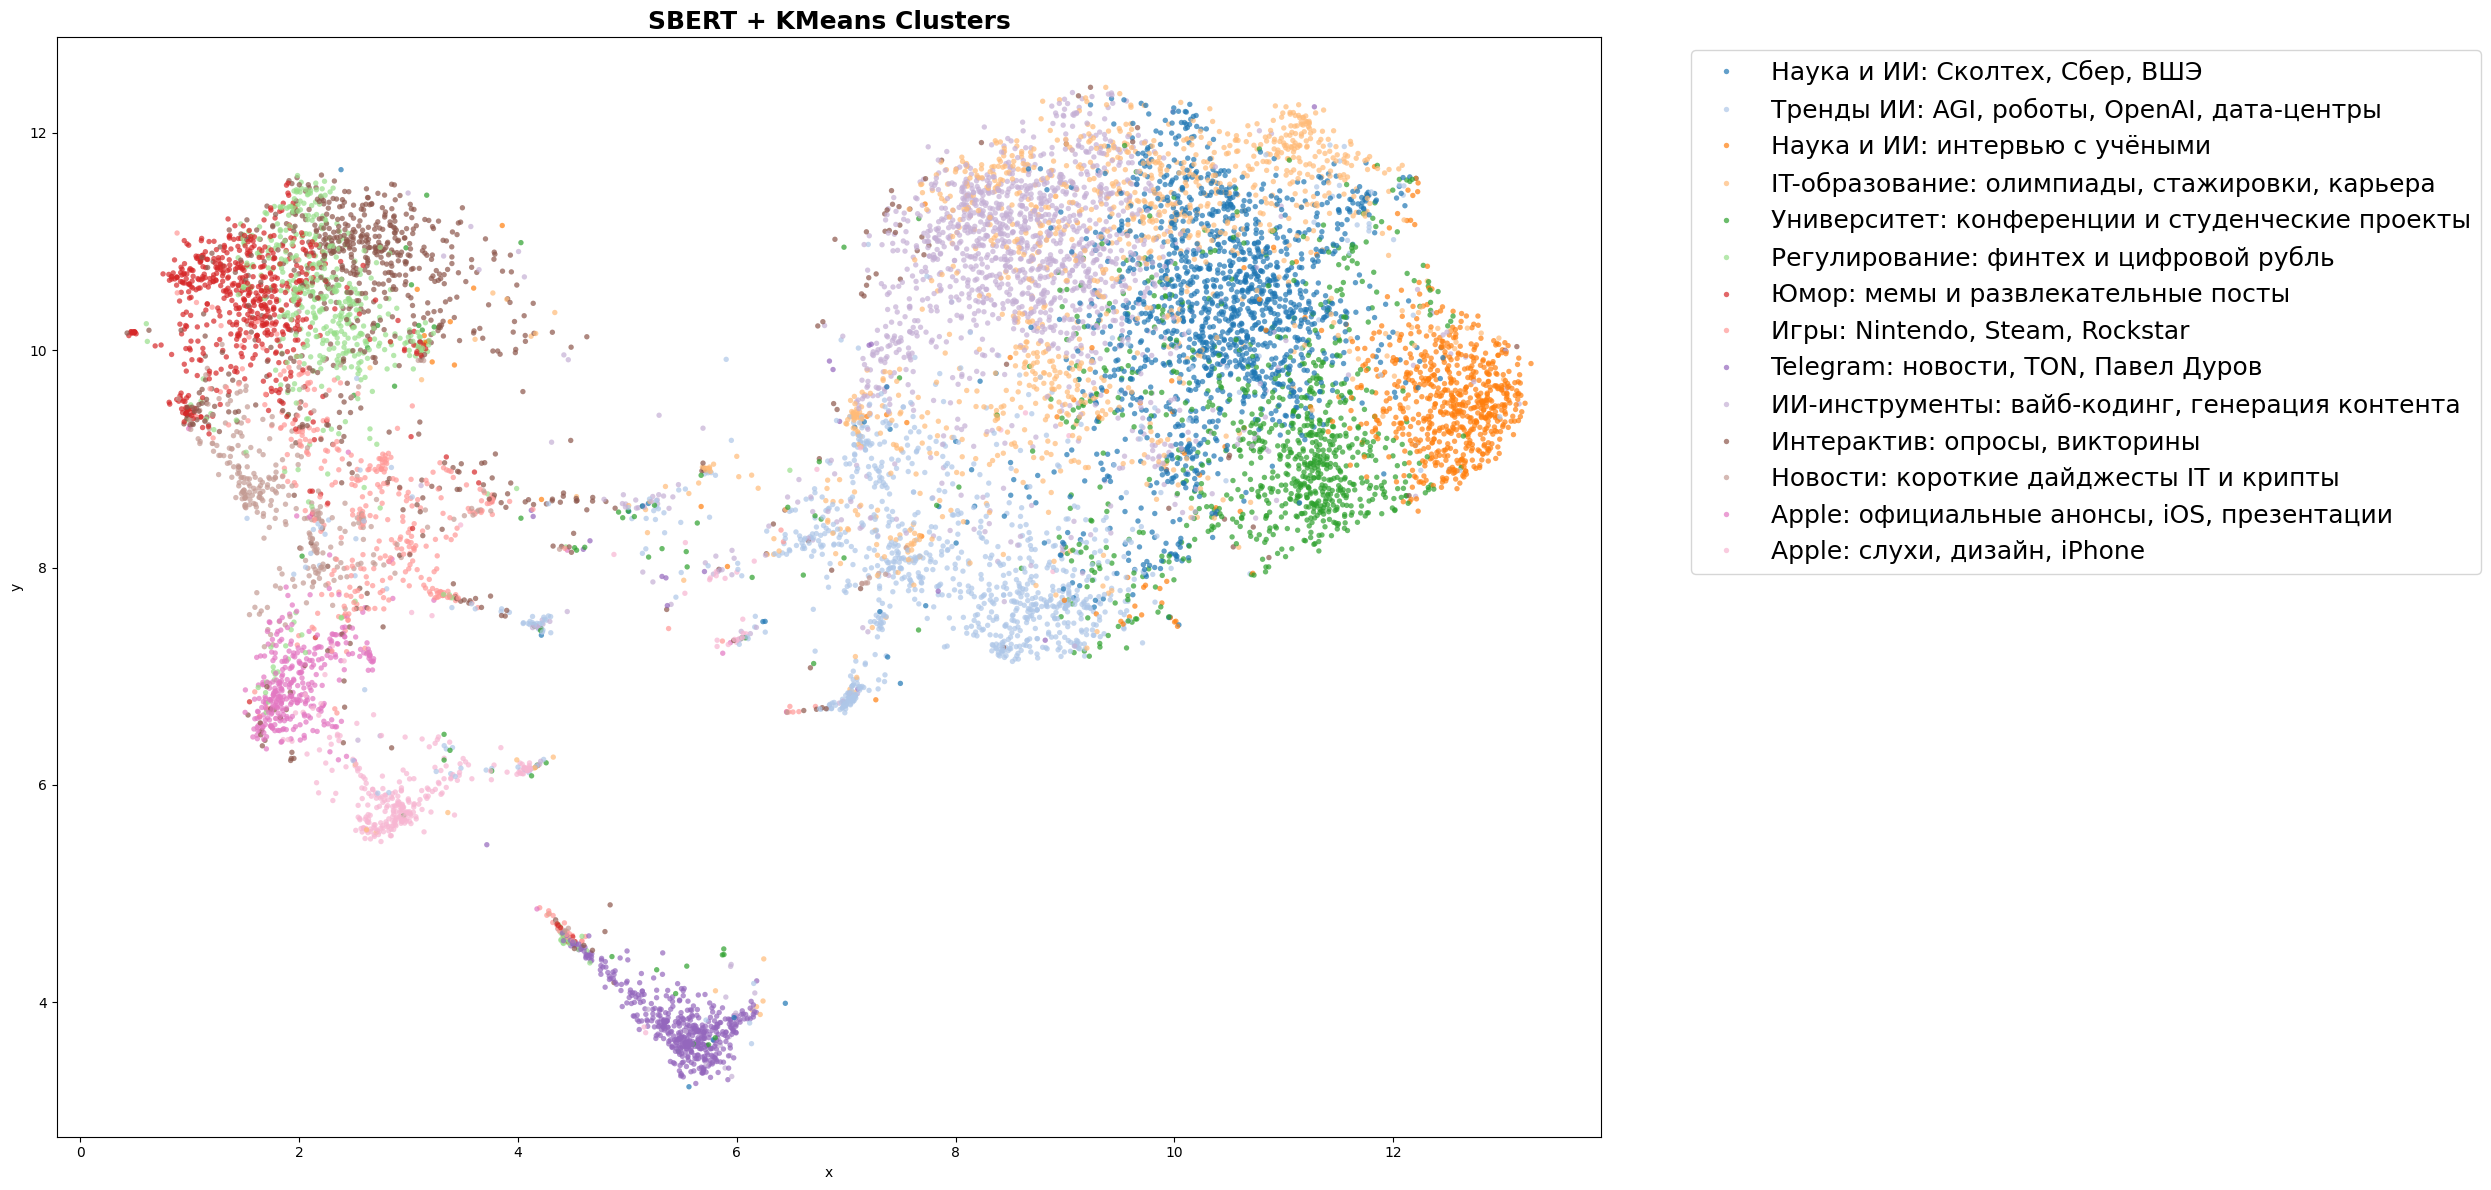

In [28]:
import umap.umap_ as umap

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = umap_reducer.fit_transform(
    X_sbert_final
)

plot_df = pd.DataFrame({

    'x': X_umap[:, 0],

    'y': X_umap[:, 1],

    'cluster_name':
        df_cluster_final[
            'cluster_sbert_name'
        ]

})

plt.figure(figsize=(25, 12))

sns.scatterplot(

    data=plot_df,

    x='x',

    y='y',

    hue='cluster_name',

    palette='tab20',

    s=15,

    alpha=0.7,

    linewidth=0

)

plt.title(
    'SBERT + KMeans Clusters',
    fontsize=18,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=18
)

plt.tight_layout()

os.makedirs(
    "../data/plots/sbert/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/sbert/kmeans/"
    "sbert_kmeans_final_umap.png",
    dpi=200,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

# HDBSCAN для SBERT

In [ ]:
min_cluster_sizes = [100, 150, 200]

min_samples_list = [1, 3, 5]

umap_n_neighbors = [50, 100, 150]

umap_n_components = [10, 15, 20]


In [147]:
from hdbscan.validity import validity_index
import warnings
import hdbscan
from umap import UMAP

warnings.filterwarnings("ignore")

results_hdbscan = []

for nn in umap_n_neighbors:

    for nc in umap_n_components:

        print("=" * 80)
        print(f"UMAP neighbors={nn}, components={nc}")

        umap_model = UMAP(

            n_neighbors=nn,

            n_components=nc,

            min_dist=0.1,

            metric='cosine',

            random_state=42
        )

        X_umap = umap_model.fit_transform(
            X_sbert_norm
        )

        X_umap = X_umap.astype(np.float64)

        for mcs in min_cluster_sizes:

            for ms in min_samples_list:

                clusterer = hdbscan.HDBSCAN(

                    min_cluster_size=mcs,

                    min_samples=ms,

                    metric='euclidean',

                    cluster_selection_method='eom',

                    prediction_data=True,

                    core_dist_n_jobs=-1
                )

                labels = clusterer.fit_predict(
                    X_umap
                )

                n_clusters = len(
                    set(labels)
                ) - (1 if -1 in labels else 0)

                noise_ratio = np.mean(
                    labels == -1
                )

                sil = np.nan
                dbcv = np.nan

                valid_mask = labels != -1

                unique_valid = np.unique(
                    labels[valid_mask]
                )

                if len(unique_valid) >= 2:

                    try:

                        sil = silhouette_score(

                            X_umap[valid_mask],

                            labels[valid_mask],

                            metric='euclidean'
                        )

                    except:

                        pass

                try:

                    dbcv = validity_index(
                        X_umap,
                        labels
                    )

                except:

                    pass

                results_hdbscan.append({

                    'umap_neighbors': nn,

                    'umap_components': nc,

                    'min_cluster_size': mcs,

                    'min_samples': ms,

                    'n_clusters': n_clusters,

                    'noise_ratio': noise_ratio,

                    'silhouette': sil,

                    'dbcv': dbcv
                })

UMAP neighbors=50, components=10
UMAP neighbors=50, components=15
UMAP neighbors=50, components=20
UMAP neighbors=100, components=10
UMAP neighbors=100, components=15
UMAP neighbors=100, components=20
UMAP neighbors=150, components=10
UMAP neighbors=150, components=15
UMAP neighbors=150, components=20


In [148]:
df_hdbscan = pd.DataFrame(
    results_hdbscan
)

os.makedirs(
    "../data/results/metrics/sbert",
    exist_ok=True
)

df_hdbscan.to_csv(

    "../data/results/metrics/sbert/"
    "sbert_hdbscan_metrics.csv",

    index=False
)

df_hdbscan.head()

,umap_neighbors,umap_components,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,50,10,100,1,2,0.005350,0.414221,0.070843
1,50,10,100,3,2,0.005350,0.414221,0.070843
2,50,10,100,5,2,0.002962,0.412705,-0.299640
3,50,10,150,1,2,0.005350,0.414221,0.070843
4,50,10,150,3,2,0.005350,0.414221,0.070843


In [160]:
df_hdbscan_filtered = df_hdbscan[

    (df_hdbscan['n_clusters'] >= 5) &
    (df_hdbscan['n_clusters'] <= 20) &
    (df_hdbscan['noise_ratio'] <= 0.50) & 
    (df_hdbscan['dbcv'] >= 0) &
    (df_hdbscan['silhouette'] >= 0.30)

].sort_values(

    ['dbcv', 'silhouette'],
    ascending=False

)

df_hdbscan_filtered.reset_index(drop=True)

,umap_neighbors,umap_components,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,100,15,100,3,6,0.271807,0.494785,0.099674
1,100,20,100,1,13,0.451992,0.406366,0.085231
2,100,20,200,5,7,0.464603,0.453300,0.083366
3,100,20,150,5,8,0.466323,0.456452,0.079030
4,150,20,100,5,9,0.479603,0.445744,0.073851
5,150,15,200,3,8,0.479029,0.448276,0.053775
6,100,20,150,3,7,0.438426,0.436280,0.033082
7,100,20,200,3,7,0.438426,0.436280,0.033082
8,150,20,150,3,8,0.470622,0.438623,0.005089


Рассмотрим примеры кластеров для первых 4 вариантов

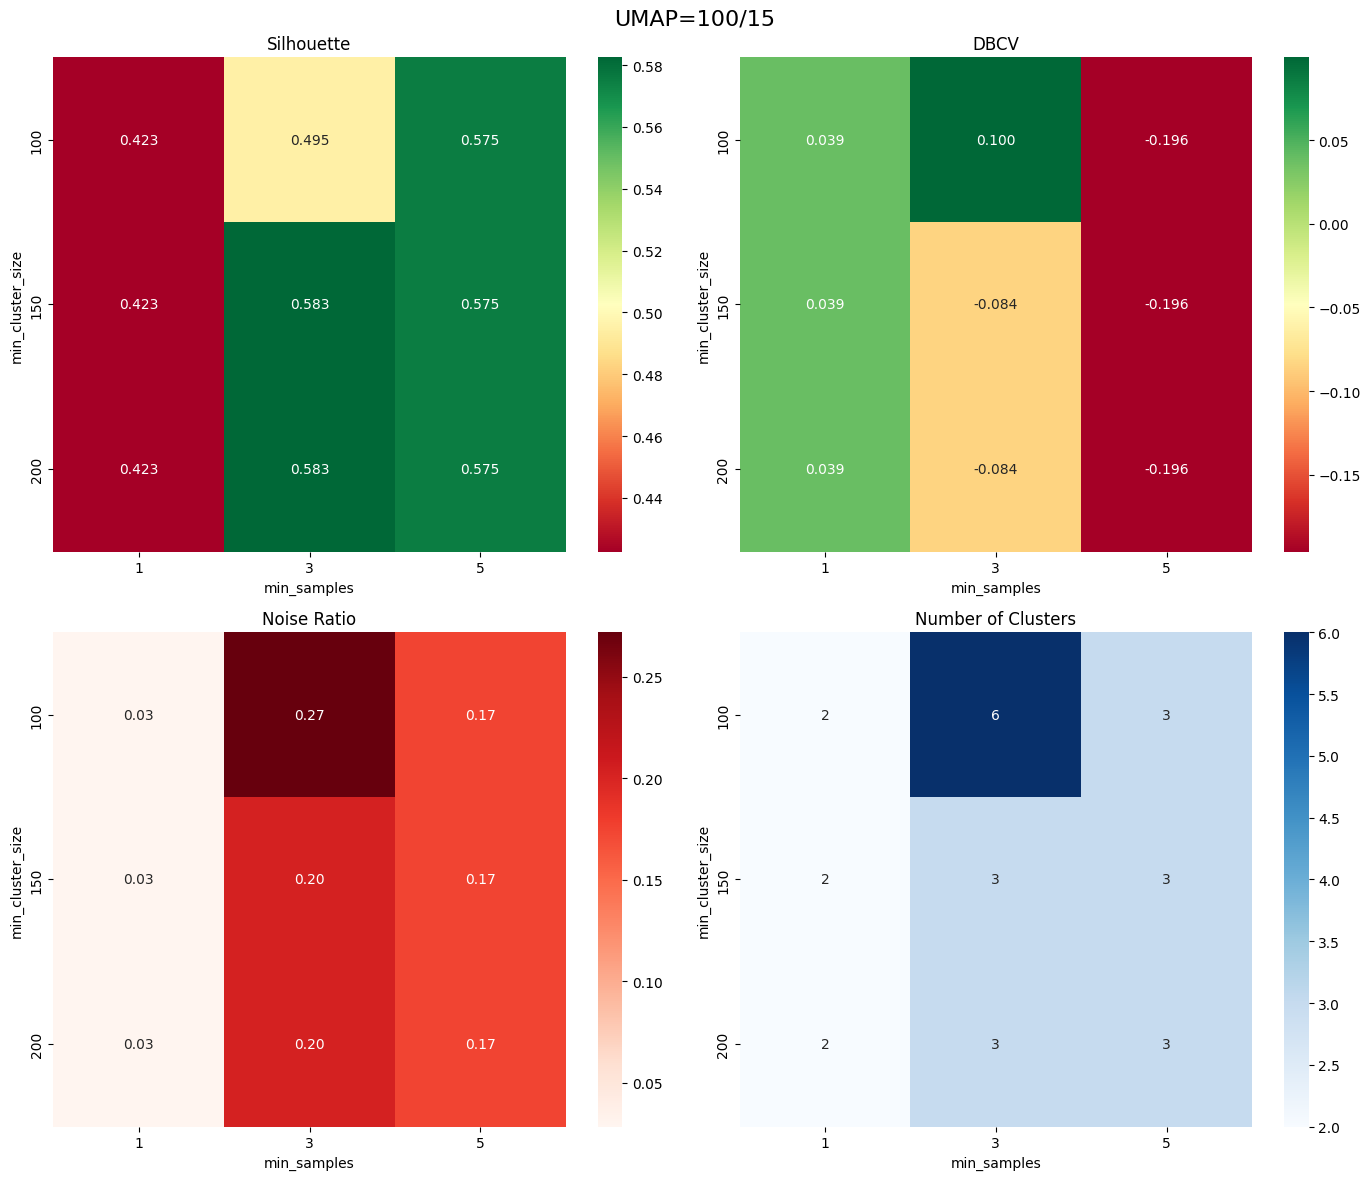

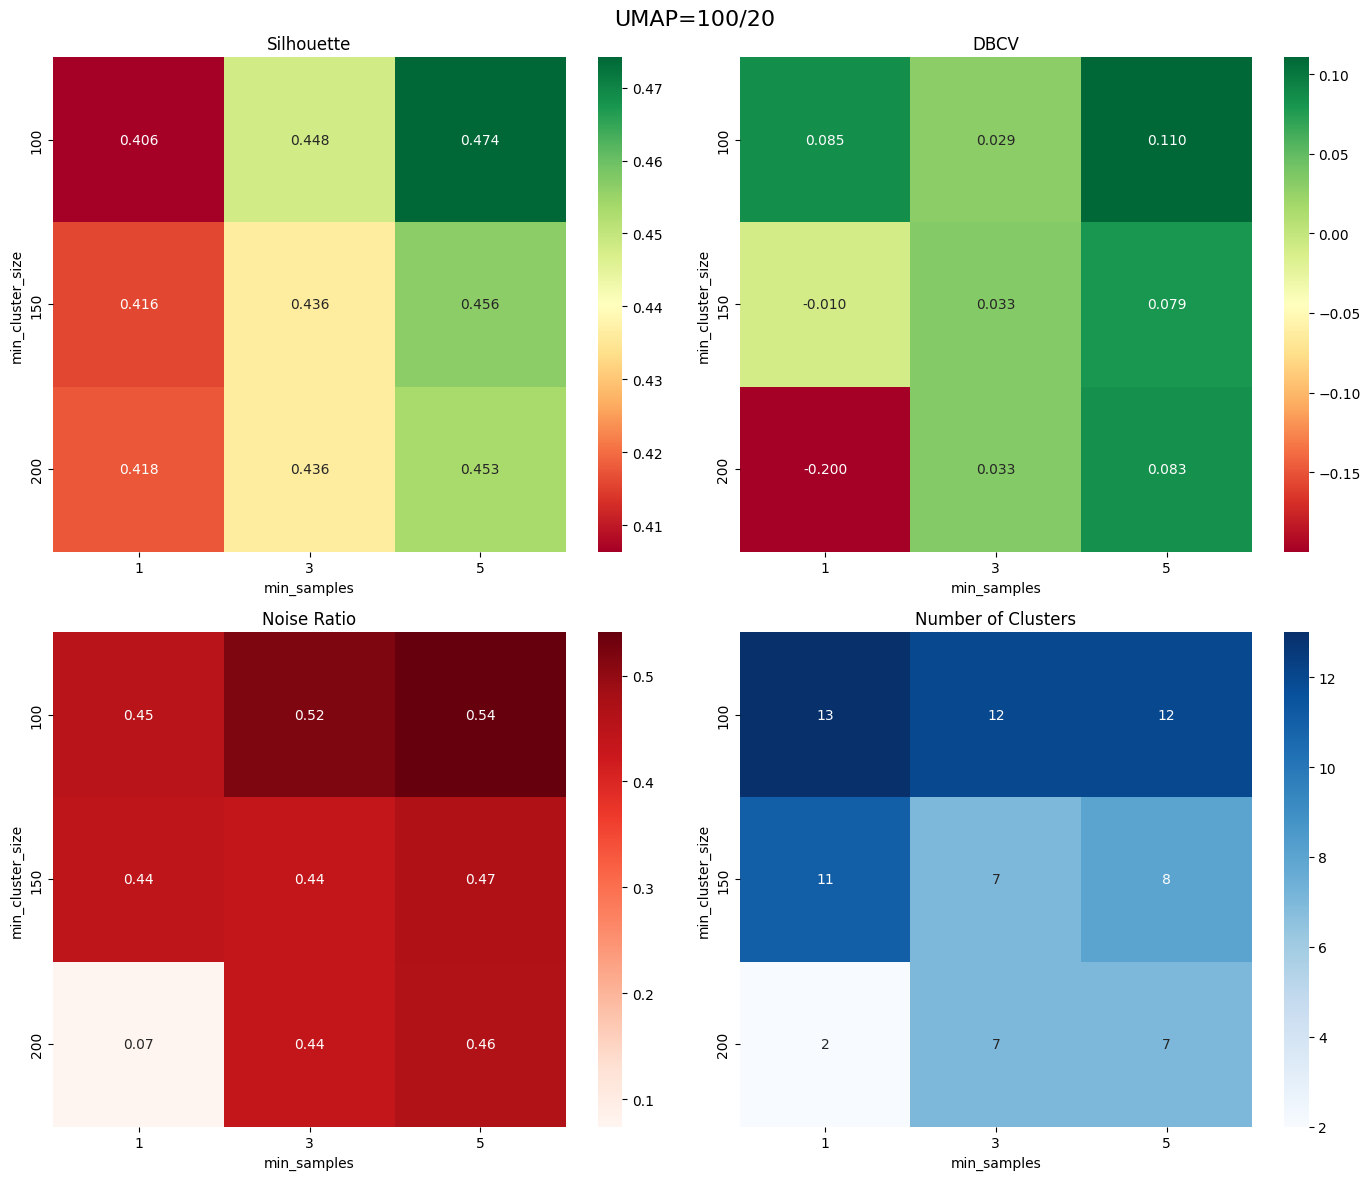

In [ ]:
top_configs = df_hdbscan_filtered[
    [
        'umap_neighbors',
        'umap_components'
    ]
].head(4).drop_duplicates()

for _, row in top_configs.iterrows():

    nn = row['umap_neighbors']
    nc = row['umap_components']

    subset = df_hdbscan[

        (df_hdbscan['umap_neighbors'] == nn) &
        (df_hdbscan['umap_components'] == nc)

    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 12)
    )


    # SILHOUETTE
    pivot_sil = subset.pivot_table(
        values='silhouette',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_sil,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[0, 0]
    )

    axes[0, 0].set_title(
        'Silhouette'
    )

    # DBCV
    pivot_dbcv = subset.pivot_table(
        values='dbcv',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_dbcv,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[0, 1]
    )

    axes[0, 1].set_title(
        'DBCV'
    )

    # NOISE
    pivot_noise = subset.pivot_table(
        values='noise_ratio',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_noise,
        annot=True,
        fmt='.2f',
        cmap='Reds',
        ax=axes[1, 0]
    )

    axes[1, 0].set_title(
        'Noise Ratio'
    )

    # N CLUSTERS
    pivot_clusters = subset.pivot_table(
        values='n_clusters',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_clusters,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        ax=axes[1, 1]
    )

    axes[1, 1].set_title(
        'Number of Clusters'
    )

    plt.suptitle(

        f'UMAP={nn}/{nc}',

        fontsize=16
    )

    plt.tight_layout()

    os.makedirs(
        "../data/plots/sbert/hdbscan",
        exist_ok=True
    )

    plt.savefig(

        f"../data/plots/sbert/hdbscan/"
        f"heatmap_umap_{nn}_{nc}.png",

        dpi=200,

        bbox_inches='tight'
    )

    plt.show()

Посмотрим на примеры кластеров

In [29]:
candidate_configs = [
    {
        "umap_neighbors": 100,
        "umap_components": 15,
        "min_cluster_size": 100,
        "min_samples": 3
    },

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 100,
        "min_samples": 1
    },
    
    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 200,
        "min_samples": 5
    },

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 150,
        "min_samples": 5
    }
]

In [ ]:
os.makedirs(
    "../data/results/candidate_examples/sbert_hdbscan",
    exist_ok=True
)

for cfg in candidate_configs:

    nn = cfg['umap_neighbors']
    nc = cfg['umap_components']

    mcs = cfg['min_cluster_size']
    ms = cfg['min_samples']

    print("=" * 80)

    print(
        f"UMAP={nn}/{nc} | "
        f"MCS={mcs} | "
        f"MS={ms}"
    )


    umap_model = UMAP(
        n_neighbors=nn,
        n_components=nc,
        min_dist=0.1,
        metric='cosine',
        random_state=RANDOM_STATE
    )

    X_umap = umap_model.fit_transform(
        X_sbert_norm
    )

    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True,
        core_dist_n_jobs=-1
    )

    labels = clusterer.fit_predict(
        X_umap
    )
    

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(cluster_sizes)

    non_noise_mask = labels != -1
    centroid_examples = get_centroid_examples(
        X_umap[non_noise_mask],
        labels[non_noise_mask],
        df[non_noise_mask].reset_index(drop=True),
        n_examples=50
    )

    output_path = (
        "../data/results/candidate_examples/"
        "sbert_hdbscan/"

        f"sbert_hdbscan_"
        f"umap{nn}_{nc}_"
        f"mcs{mcs}_"
        f"ms{ms}.txt"
    )

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("=" * 80 + "\n")
        f.write(
            "SBERT + UMAP + HDBSCAN\n")
        f.write("=" * 80 + "\n\n")
        f.write(
            f"UMAP neighbors: {nn}\n")
        f.write(
            f"UMAP components: {nc}\n")
        f.write(
            f"min_cluster_size: {mcs}\n")
        f.write(
            f"min_samples: {ms}\n\n")

        f.write("CLUSTER SIZES:\n\n")

        for cid, size in cluster_sizes.items():

            f.write(
                f"Cluster {cid}: "
                f"{size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        # EXAMPLES
        for cid in sorted(
            centroid_examples.keys()
        ):

            f.write(f"\n{'='*80}\n")

            f.write(
                f"CLUSTER {cid}\n"
            )

            f.write(f"{'='*80}\n\n")

            texts = centroid_examples[
                cid
            ]['texts']

            distances = centroid_examples[
                cid
            ]['distances']

            for i, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(

                    str(text)

                    .replace('\n', ' ')

                    .split()
                )

                f.write(
                    f"[{i+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(
                    f"{clean_text}\n\n"
                )

UMAP=100/15 | MCS=100 | MS=3
-1    2845
 0     569
 1    5099
 2     107
 3    1108
 4     189
 5     550
Name: count, dtype: int64
UMAP=100/20 | MCS=100 | MS=1
-1     4731
 0      567
 1      114
 2      152
 3      337
 4      416
 5      852
 6     1092
 7      217
 8      985
 9      263
 10     356
 11     141
 12     244
Name: count, dtype: int64
UMAP=100/20 | MCS=200 | MS=5
-1    4863
 0     567
 1    2654
 2     279
 3     295
 4     575
 5     256
 6     978
Name: count, dtype: int64
UMAP=100/20 | MCS=150 | MS=5
-1    4881
 0     567
 1    2654
 2     279
 3     295
 4     575
 5     256
 6     191
 7     769
Name: count, dtype: int64


При использовании английской SBERT-модели для кластеризации русскоязычных постов качество эмбеддингов ожидаемо снизилось, что объясняет высокий уровень шума и семантические слияния. 

Конфигурация с UMAP components=15, min_cluster_size=100, min_samples=3 показала наилучшие результаты по метрикам. Она выделила 6 относительно крупных кластеров (Telegram, YouTube, OpenAI, Apple, наука, смешанный), не пытаясь дробить данные там, где модель не видит уверенных связей. 

Альтернатива с min_samples=1 дала больше кластеров (13), но при 45% шума и низком качестве эмбеддингов это скорее ложная детализация и модель начала кластеризовать шум. 

Более агрессивные конфигурации (min_cluster_size=150 и 200) объединили семантически разные темы, показав, что избыточное обобщение на русском тексте ведет к потере смысла. 

Итоговая конфигурация: **components=15, min_cluster_size=100, min_samples=3**

Зафиксируем финальную версию

In [35]:
umap_model = UMAP(
    n_neighbors=100,
    n_components=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_hdbscan_final = umap_model.fit_transform(X_sbert_norm)

hdbscan_final = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    core_dist_n_jobs=-1
)

labels_hdbscan = hdbscan_final.fit_predict(X_hdbscan_final.astype(np.float64))

print("Clusters:",
      len(set(labels_hdbscan)) -
      (1 if -1 in labels_hdbscan else 0))

print("Noise ratio:",
      np.mean(labels_hdbscan == -1))

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clusters: 6
Noise ratio: 0.2718066303620904


In [36]:
df_hdbscan_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_hdbscan_cluster_final['cluster_sbert_hdbscan'] = labels_hdbscan

cluster_sizes = (
    df_hdbscan_cluster_final['cluster_sbert_hdbscan']
    .value_counts()
    .sort_index()
)

df_hdbscan_cluster_final['cluster_sbert_hdbscan_size'] = (
    df_hdbscan_cluster_final['cluster_sbert_hdbscan']
    .map(cluster_sizes)
)

Добавим названия кластеров

In [44]:
cluster_names_sbert_hdbscan = {
    -1: "Прочее / Шум",
    0: "Telegram: обновления, штрафы и Павел Дуров",
    1: "OpenAI: ChatGPT, новые модели и LLM-бенчмарки",
    2: "YouTube: видеохостинг, Netflix и сериалы",
    3: "Apple: iPhone, iOS и другие устройства",
    4: "Наука и Сколтех: исследования и ИИ в науке",
    5: "Сборная: дайджесты, игры, Android, Xiaomi, Google"
}

In [45]:
df_hdbscan_cluster_final['cluster_sbert_hdbscan_name'] = (
    df_hdbscan_cluster_final['cluster_sbert_hdbscan']
    .map(cluster_names_sbert_hdbscan)
)

Посмотрим на распределение кластеров

In [46]:
distribution = (
    df_hdbscan_cluster_final[
        [
            'cluster_sbert_hdbscan',
            'cluster_sbert_hdbscan_name',
            'cluster_sbert_hdbscan_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_sbert_hdbscan')
)

distribution

,cluster_sbert_hdbscan,cluster_sbert_hdbscan_name,cluster_sbert_hdbscan_size
0,-1,Прочее / Шум,2845
125,0,"Telegram: обновления, штрафы и Павел Дуров",569
1,1,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки",5099
307,2,"YouTube: видеохостинг, Netflix и сериалы",107
33,3,"Apple: iPhone, iOS и другие устройства",1108
840,4,Наука и Сколтех: исследования и ИИ в науке,189
763,5,"Сборная: дайджесты, игры, Android, Xiaomi, Google",550


Сохраним

In [47]:
os.makedirs(
    "../data/results/final_clusters/sbert_hdbscan",
    exist_ok=True
)

output_csv = (
    "../data/results/final_clusters/"
    "sbert_hdbscan/sbert_hdbscan_final_clusters.csv"
)

df_hdbscan_cluster_final.to_csv(
    output_csv,
    index=False
)

Визуализация

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


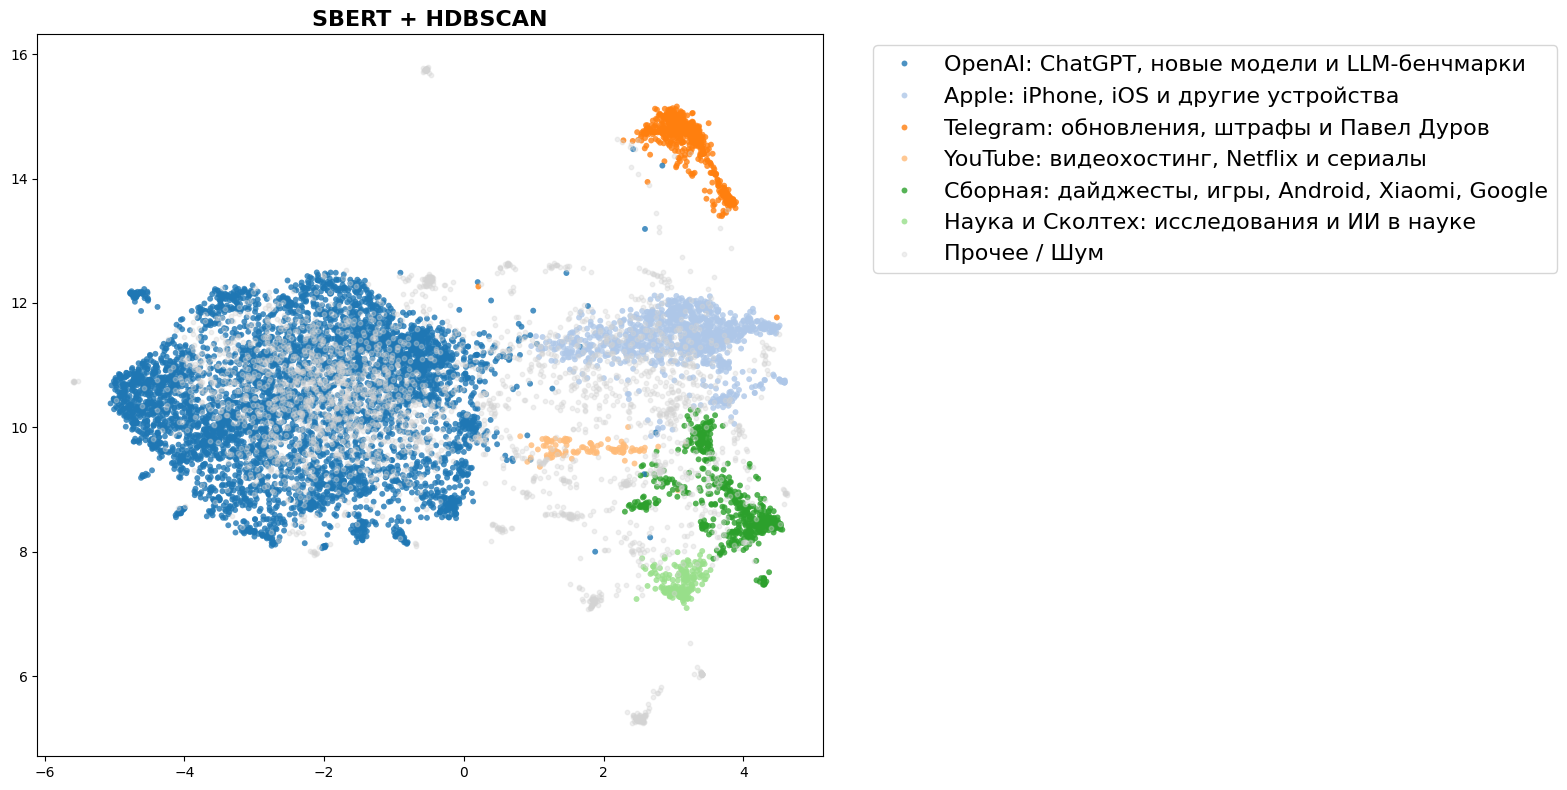

In [49]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = umap_reducer.fit_transform(
    X_sbert_norm
)

plt.figure(figsize=(16, 8))

mask_clusters = labels_hdbscan != -1

hue_names = pd.Series(labels_hdbscan).map(cluster_names_sbert_hdbscan)

sns.scatterplot(
    x=X_umap[mask_clusters, 0],
    y=X_umap[mask_clusters, 1],
    hue=hue_names[mask_clusters],
    palette='tab20',
    s=18,
    alpha=0.8,
    linewidth=0
)

mask_noise = labels_hdbscan == -1
plt.scatter(
    X_umap[mask_noise, 0],
    X_umap[mask_noise, 1],
    c='lightgray',
    s=10,
    alpha=0.35,
    label='Прочее / Шум'
)

plt.title(
    'SBERT + HDBSCAN',
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=16
)

plt.tight_layout()

os.makedirs(
    "../data/plots/sbert/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/sbert/hdbscan/"
    "sbert_hdbscan_umap.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()


Для практического анализа терять треть данных нецелесообразно. Поэтому применяем постобработку: вычисляем центроиды кластеров и присваиваем каждому шумовому посту ближайший кластер по косинусному расстоянию.

Центроиды имеющихся кластеров

In [181]:
valid_mask = labels_hdbscan != -1

X_core = X_hdbscan_final[valid_mask]
labels_core = labels_hdbscan[valid_mask]

centroids = {}

for c in np.unique(labels_core):

    centroids[c] = X_core[labels_core == c].mean(axis=0)

Присваиваем шум к ближайшим центроидам

In [182]:
from sklearn.metrics.pairwise import cosine_distances

X_noise = X_hdbscan_final[labels_hdbscan == -1]

noise_indices = np.where(labels_hdbscan == -1)[0]

assigned_clusters = []

for i in range(len(X_noise)):

    dists = []

    for c in centroids:

        dist = cosine_distances(
            X_noise[i].reshape(1, -1),
            centroids[c].reshape(1, -1)
        )[0][0]

        dists.append((c, dist))

    best_cluster = min(dists, key=lambda x: x[1])[0]
    assigned_clusters.append(best_cluster)

assigned_clusters = np.array(assigned_clusters)


Добавляем колонку в датафрейм

In [183]:
labels_hdbscan_final = labels_hdbscan.copy()

labels_hdbscan_final[labels_hdbscan_final == -1] = assigned_clusters


df_hdbscan_cluster_final['cluster_sbert_hdbscan_final'] = labels_hdbscan_final

In [184]:
cluster_sizes_final = (
    df_hdbscan_cluster_final['cluster_sbert_hdbscan_final']
    .value_counts()
    .sort_index()
)

df_hdbscan_cluster_final['cluster_sbert_hdbscan_final_size'] = (
    df_hdbscan_cluster_final['cluster_sbert_hdbscan_final']
    .map(cluster_sizes_final)
)

df_hdbscan_cluster_final['cluster_sbert_hdbscan_final_name'] = (
    df_hdbscan_cluster_final['cluster_sbert_hdbscan_final']
    .map(cluster_names_sbert_hdbscan)
)

df_hdbscan_cluster_final.head()

,post_id,channel_username,text,cluster_sbert_hdbscan,cluster_sbert_hdbscan_size,cluster_sbert_hdbscan_name,cluster_sbert_hdbscan_final,cluster_sbert_hdbscan_final_size,cluster_sbert_hdbscan_final_name
0,1813,AI_point_of_view,🤔 Искусственный интеллект: угроза или новые во...,-1,2845,NaN,1,6879,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки"
1,1809,AI_point_of_view,👩‍🎓 **Самообучение без разметки: лекция Алексе...,1,5099,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки",1,6879,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки"
2,1808,AI_point_of_view,📡▶️ **Искусственный интеллект: как научить маш...,1,5099,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки",1,6879,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки"
3,1805,AI_point_of_view,*️⃣**Физика + ИИ** **от Сколтеха** **Владимир ...,1,5099,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки",1,6879,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки"
4,1804,AI_point_of_view,⚡️**ЗАВТРА:** **Sber Conf: Open Source & AI Ag...,1,5099,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки",1,6879,"OpenAI: ChatGPT, новые модели и LLM-бенчмарки"


Сохраняем

In [185]:
output_final = (
    "../data/results/final_clusters/sbert_hdbscan/"
    "sbert_hdbscan_final_clusters_no_noise.csv"
)

df_hdbscan_cluster_final.to_csv(output_final, index=False)

Посмотрим на итоговое распределение

In [186]:
df_hdbscan_cluster_final[
    'cluster_sbert_hdbscan_final_name'
].value_counts()


cluster_sbert_hdbscan_final_name
OpenAI: ChatGPT, новые модели и LLM-бенчмарки        6879
Apple: iPhone, iOS и другие устройства               1525
Сборная: дайджесты, игры, Android, Xiaomi, Google     755
Telegram: обновления, штрафы и Павел Дуров            569
Наука и Сколтех: исследования и ИИ в науке            387
YouTube: видеохостинг, Netflix и сериалы              352
Name: count, dtype: int64

Визуализируем теперь без шума

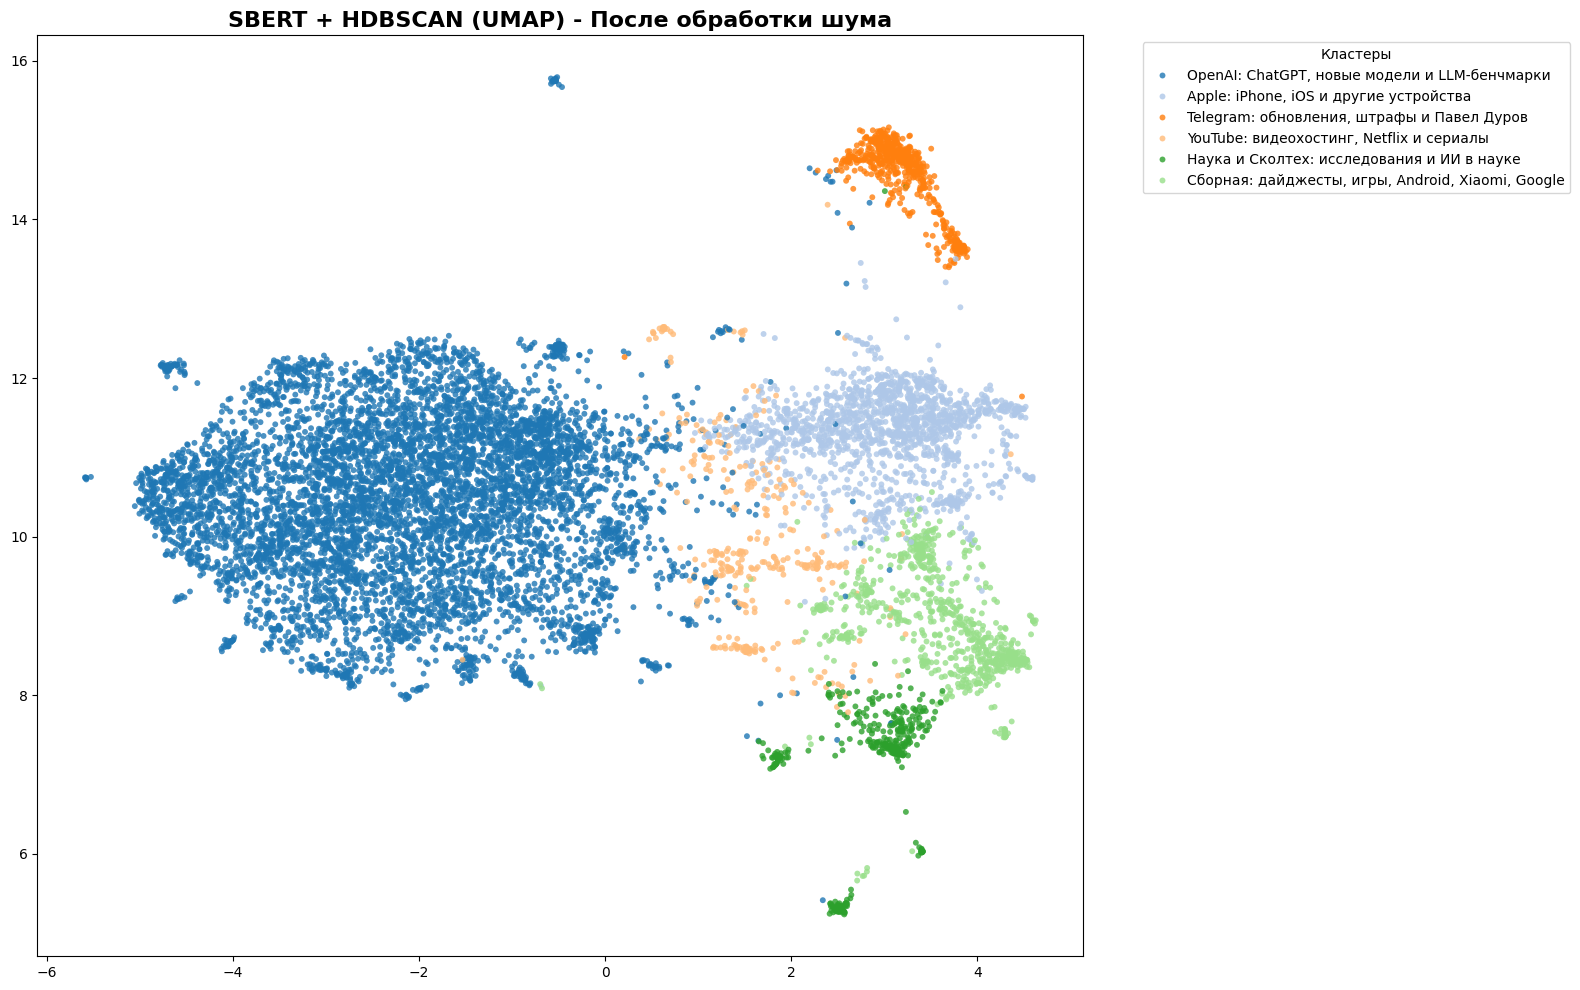

In [187]:
X_umap_final = umap_reducer.fit_transform(X_sbert_norm)

plt.figure(figsize=(16, 10))

labels_final = labels_hdbscan_final

hue_names_final = pd.Series(labels_final).map(cluster_names_sbert_hdbscan)

sns.scatterplot(
    x=X_umap_final[:, 0],
    y=X_umap_final[:, 1],
    hue=hue_names_final,
    palette='tab20',
    s=18,
    alpha=0.8,
    linewidth=0
)

plt.title(
    'SBERT + HDBSCAN (UMAP) - После обработки шума',
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Кластеры'
)

plt.tight_layout()

os.makedirs(
    "../data/plots/sbert/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/sbert/hdbscan/"
    "sbert_hdbscan_umap_final_no_noise.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()